<a href="https://colab.research.google.com/github/Thavisha72/Global-Tsunami-prediction/blob/main/Global_Tsunami_Prediction_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Global Tsunami Prediction and EDA

Thavisha Nipun Bandara

Individual Project

In [ ]:
# Loading the data set

import pandas as pd

url = "https://raw.githubusercontent.com/Thavisha72/Global-Tsunami-prediction/main/earthquake_data_tsunami.csv"

data = pd.read_csv(url)

In [ ]:
print(data.head())
print('-'*50)
print("\nShape:", data.shape)
print('-'*50)
print("\nColomns:", data.columns)
print('-'*50)
print("\nData types:", data.dtypes)

   magnitude  cdi  mmi  sig  nst   dmin   gap    depth  latitude  longitude  \
0        7.0    8    7  768  117  0.509  17.0   14.000   -9.7963    159.596   
1        6.9    4    4  735   99  2.229  34.0   25.000   -4.9559    100.738   
2        7.0    3    3  755  147  3.125  18.0  579.000  -20.0508   -178.346   
3        7.3    5    5  833  149  1.865  21.0   37.000  -19.2918   -172.129   
4        6.6    0    2  670  131  4.998  27.0  624.464  -25.5948    178.278   

   Year  Month  tsunami  
0  2022     11        1  
1  2022     11        0  
2  2022     11        1  
3  2022     11        1  
4  2022     11        1  
--------------------------------------------------

Shape: (782, 13)
--------------------------------------------------

Colomns: Index(['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude', 'Year', 'Month', 'tsunami'],
      dtype='object')
--------------------------------------------------

Data types: magnitude    float64

## Data Preprocessing

In [ ]:
#handling missing values
null_val= data.isnull().sum()
print(null_val)

magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64


In [ ]:
# duplicates

print("Duplicates", data.duplicated().sum())

Duplicates 0


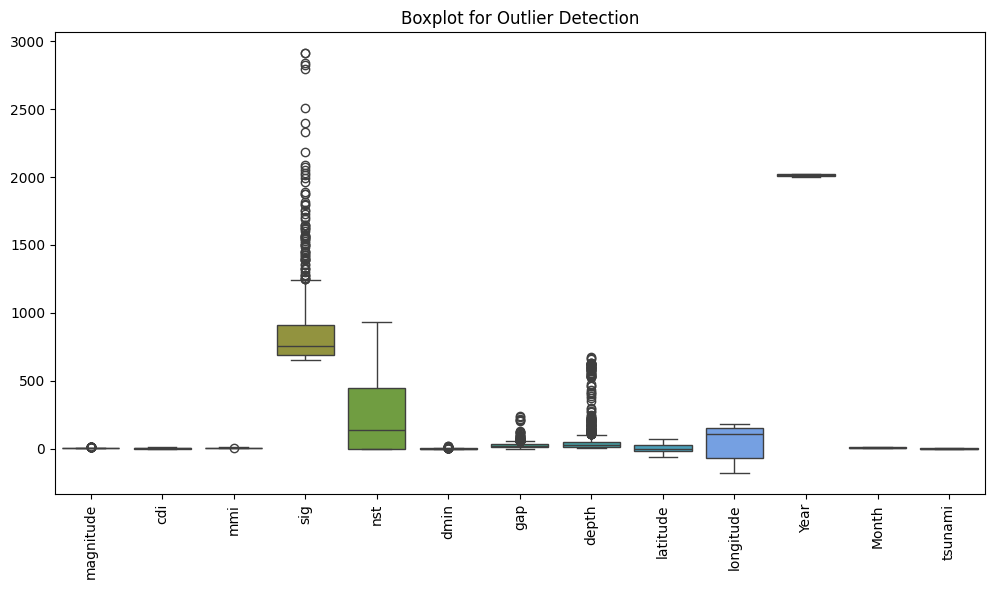

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = data.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=data[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [ ]:
# checking for outliers

import numpy as np

columns = data.select_dtypes(include=np.number).columns

for column in columns:
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR

  data_new = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

print(data_new.shape)


(782, 13)


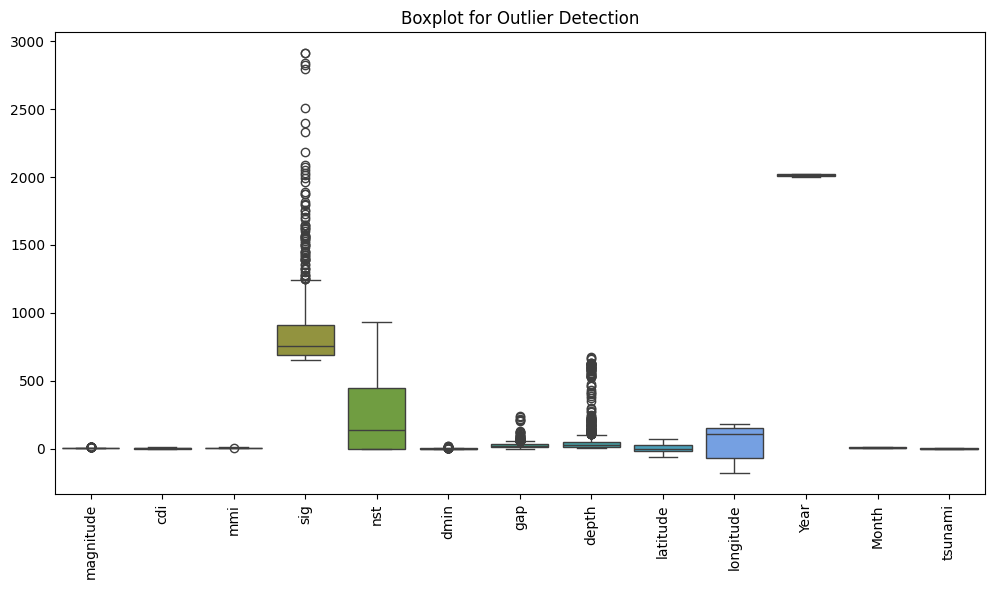

In [ ]:
num_cols = data_new.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=data_new[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [ ]:
data_new.head()


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


<function matplotlib.pyplot.show(close=None, block=None)>

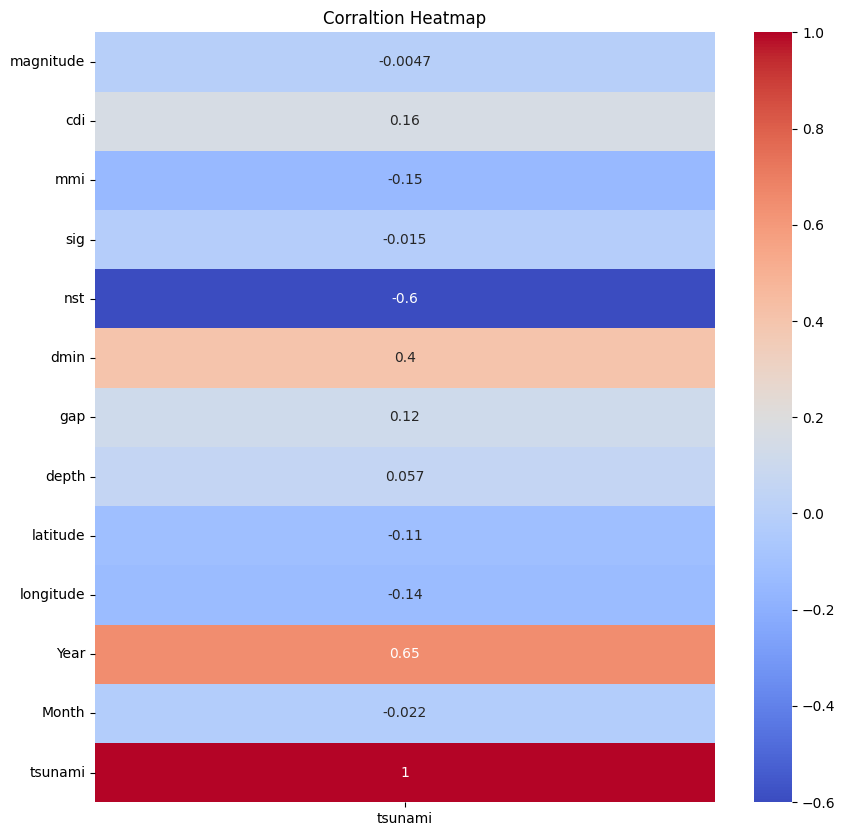

In [ ]:
corr = data_new.corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr[["tsunami"]], annot=True, cmap='coolwarm')
plt.title("Corraltion Heatmap")
plt.show

In [ ]:
# convert numerical values to Categerical Values

labels = {0: 'No Tsunami', 1: 'Tsunami'}
data_new['tsunami'] = data_new['tsunami'].map(labels)

print(data_new.head())


   magnitude  cdi  mmi  sig  nst   dmin   gap    depth  latitude  longitude  \
0        7.0    8    7  768  117  0.509  17.0   14.000   -9.7963    159.596   
1        6.9    4    4  735   99  2.229  34.0   25.000   -4.9559    100.738   
2        7.0    3    3  755  147  3.125  18.0  579.000  -20.0508   -178.346   
3        7.3    5    5  833  149  1.865  21.0   37.000  -19.2918   -172.129   
4        6.6    0    2  670  131  4.998  27.0  624.464  -25.5948    178.278   

   Year  Month     tsunami  
0  2022     11     Tsunami  
1  2022     11  No Tsunami  
2  2022     11     Tsunami  
3  2022     11     Tsunami  
4  2022     11     Tsunami  


## Training ML models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

# Revert 'tsunami' column to numerical values (0 and 1) for splitting
data_new['tsunami'] = data_new['tsunami'].map({'No Tsunami': 0, 'Tsunami': 1})

#target
y = data_new['tsunami'].astype(int)

# features
X = data_new.drop("tsunami", axis=1)

# splitting

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## Comparing Multiple Models

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SCV
from sklearn.tree import DecisionTreeClassifier

models = {
    "LogisticRegression": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    "SVC": SVC(),
    "DecisionTree": DecisionTreeClassifier()
}

for name,  models in models.items():
  models.fit(X_train , y_train)
  y_prod = models.predict(X_test)


results.append({
    'Model': name,
    'Accuracy': accuracy_score(y_test, y_train)